<a href="https://colab.research.google.com/github/ilaydacepniogluu-sys/AkademiQ_DataScience/blob/main/AkademiQ6HAFTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Etiketsiz veriden yapı çıkartmak

Denetimsiz öğrenme,veriye herhangi bir etiket verilmeksizin içindeki gizli yapıyı keşfeder. Benzer noktaları gruplamak, yüksek boyutlu veriyi anlaşılır bir uzaya indirgemek, sıra dışı gözlemleri tespit etmek; bunların hepsi bu kategoride yer alır. Üç demo, kümeleme ve boyut indirgemenin farklı yaklaşımlarını karşılaştırmalı olarak sunar.


K-MEANS: iki adımı birbirini destekleyene dek tekrarlar: (1) her noktayı en yakın merkeze ata, (2) her merkezin yeni konumunu atanan noktaların ağırlık merkezine taşı. Bu döngü, merkezler hareketsiz kalana dek sürer; bu ana yakınsama denir.(asıl amacı birbirine yakın noktaları aynı merkez etrafında toplayabilmek)


PCA:Verilerin en fazla "saçıldığı" doğrultuyu arar. PCI ekseni bu doğrultudur; PC2 buna dik olan ikinci en yüksek varyans yönüdür.Boyut indirgemek, her noktayı PCI üzerine yansıtmak anlamına gelir: tek boyutlu bir koordinat elde edilir, ancak bilgi tam korunmaz.Yeniden kurulum bağlantıları neyin kaybolduğunu gösterir.(temek mantık şu; bu veride en fazla bilgi hangi yönde taşınıyor.)


DBSCAN: Bir noktayı "core" ilan eder eğer epsilon yarıçaplı dairesinde en az minPts komşu varsa. Core pointler birbirine bağlanarak küme oluşturur. Bir noktanın komşusu olan ama kendisi core olmayan noktalar "border"; kimsenin erişemediği noktalar ise "noise" etiketini alır. K-means'in aksine küme sayısını önceden belirlemeye gerek yoktur.
not: epsilon=yakınlık mesafesi.


#K-MEANS

K-Means modern veri biliminin en klasik clustering algoritmasıdır.


En güçlü olduğu yer:

1)Müşteri segmentasyonu

2)davranış gruplama

3)recommendation systems

4)marketing analizi

Bu yüzden: Google, Amazon , Netflix gibi şirketlerde büyük ölçekli segmentasyon sistemlerinde yoğun kullanılır.

K-Means: "Her cluster küreseldir." varsayımı yapar.

Yani: Gerçek dünyadaki karmaşık geometrileri anlamakta zorlanır.

Ayrıca: Outlier'lar merkezi bozabilir.

Bu nedenle production sistemlerinde:

*Scaling


*Outlier cleaning


*feature enginnering
  
  kritik öneme sahiptir.



#DBSCAN

DSBCAN yoğunluk tabanlı çalışır.

En büyük farkı: Noise ve outlier'ları anlayabilmesidir.


Gerçek dünyada:

1)fraud detection

2)siber saldırı tespiti

3)üsretim anormalleri

4)loT sensör analizi

gibi alanlarda çok değerlidir.

Çünkü gerçek veri çoğu zaman temiz değildir.

DSBCAN'IN en büyük avantajı: K sayısını istememesidir.

yani: kaç cluster olduğunu kendi keşfetmeye çalışır.

Ama ktirik dezavantaj: Büyük ver, setlerinde maaliyetlidir.

Özelliklle: Milyonlarca satırlık sistemlerde hesaplama süresi ciddi artabilir.

Bu nedenle: SV seviyesinde veri ekipleri bazen:

*approximate nearest neighbor

*distributed clustering

*GPU acceleration

kullanılır.


#PCA

PCA bir clustering(clustering) algoritması değildir.

Bu çok kritik bir bilgidir.

PCA: Boyut azaltma algoritmasıdır.

Temel amacı: Verideki en yüksek bilgi taşıyan eksenleri bulmaktır.

Modern veri setlerinde: 1000+ feature olabilir.

Bu durumda:

*hesaplama maaliyeti artar.

*clustering zorlaşır.

*Mesafeler anlamsızlaşır.

Bu probleme: Curse Of Dimensionality denir.


PCA burada: Veriyi daha düşük boyuta indirir.


Avantajları;

*hız kazancı

*gürültü azaltma

*Görselleştirme

*overfitting azaltımı

Modern Al dünyasında: özellikle embedding sistemlerinde çok önemlidir.

Örnek: LLM embedding'leri.

Bir embedding: 768 veya 1536 boyutlu olabilir.

İnsan bunu anlayamaz.

Ama PCA / UMAP / T-SNE: Bunu 2D uzaya indirip görselleştirebilir.

SV seviyesinde kritik gerçek

Gerçek dünyada bu algoritmalar çoğu zaman tek başına kullanılmaz.

Modern pipeline örnekleri:

    1. PCA + KMeans Boyutu azalt-->sonra clustering yap



    2. UMAP + DBSCAN Embedding uzayını sadeleştir-->yoğunluk analizi yap.



    3. AutoEncoder + Clustering Deep Learning ile Latent representation
çıkar.



  
  Yani: Gerçek mühendislik , algoritmaları kombine edebilme becerisidr.


#ALGORİTMA SEÇİMİ NASIL YAPILMALI?

K-MEANS kullan:

*Veri büyükse

*Cluster yapıları basitse

*hız önemliyse



DBSCAN kullan

*noise varsa

*outlier önemliyse

*Karmaşık geometriler varsa


PCA kullan

*feature sayısı çok fazlaysa

*Görselleştirme gerekiyorsa

*clustering öncesi sadeleştirme isteniyorsa



SON KRİTİK NOT

Başlangıç seviyesinde insanlar "En iyi algoritma hangisi?" sorusunu sorar.


Profesyonel engineer'lar ise "Benim verim nasıl davranıyor?" sorusunu sorar.


Asıl uzmanlık algoritma ezberlemek değil, verinin geometrisini anlayabilmektir.





In [3]:
!pip install ucimlrepo -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler #bunu kullanmamızın sebebi ölçeklendirmeyi yapabilmek
from sklearn.cluster import KMeans #clustering algoritmasını import ediyor. Veriyi K tane kümeye ayıracağız.
from sklearn.decomposition import PCA


from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score #Cluster'ın kalitesini ölçer. Bir noktanın kendi cluster'ına yakınlığını ölçer ve diğer cluster'dan uzaklığı arasındaki kaliteyi ölçüyor.




In [6]:
wholesale_customers = fetch_ucirepo(id=292)

X = wholesale_customers.data.features.copy()

print("Dataset Boyutları:" , X.shape)

display(X.head())


Dataset Boyutları: (440, 7)


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


In [7]:
print(X.info())

display(X.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB
None


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#fit_transform = yukarıda oluşturduğumuz z skoru alıp veriyi inceler yani her sütunun ort. alır, standart s alır ve dağılımına bakar bu işlemi yapan fit'dir.
#transform ise gerçek dönüşümü uygular. Artık featurelerde ortalama 0 a yaklaştırılmış olur. Standart sapma da 1 e yaklaştırılmış olur.
#Bu esnada z-skor (standart skaler) tamamlanmış olur.

print(X_scaled[:5])

[[ 1.44865163  0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873
  -0.06633906]
 [ 1.44865163 -0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684
   0.08915105]
 [ 1.44865163 -0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164
   2.24329255]
 [-0.69029709  0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822
   0.09341105]
 [ 1.44865163  0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782
   1.29934689]]


#Elbow Method


Veride K sayısını bulmanın yöntemidir.

//Eğrinin kırıldığı k değeri optimale işaret eder



In [ ]:
inertia_values = []

cluster_range = range(1, 11)

for k in cluster_range:

  model =KMeans(
      n_clusters = k,
      random_state =42,
      n_init=10
  )

  model.fit(X_scaled)
  inertia_values.append(model.inertia_)

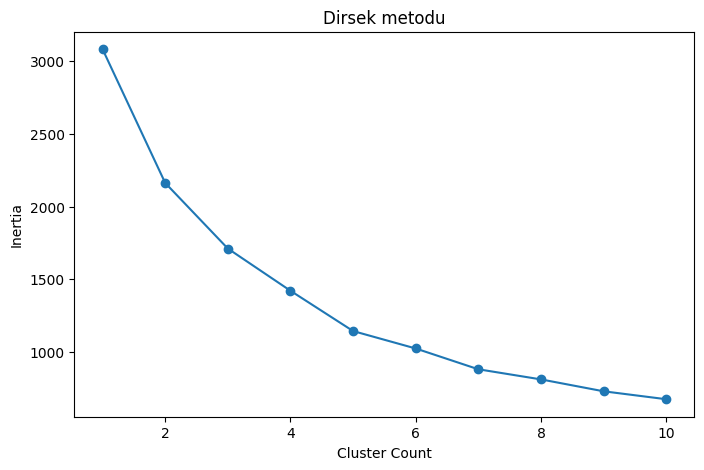

In [11]:
plt.figure(figsize= (8,5))

plt.plot(
    cluster_range,
    inertia_values,
    marker ="o"
)

plt.title("Dirsek metodu")
plt.xlabel("Cluster Count")
plt.ylabel("Inertia")

plt.show()

In [ ]:
#İnertia: KMeans'in cluster kalitesini ölçmek için kullandığımız bir ifade.
#inertia der ki: veriler kendi küme merkezlerine ne kadar yakın?
#Veri için en mantıklı cluster kaç?
#dirsek kırılmasını takip et. Kırılmanın oluştuğu nokta dirsek noktası(elbow)

In [13]:
kmeans_pipeline = Pipeline(steps=[
    (
       "kmeans",
      KMeans(
            n_clusters=4,
            random_state=42,
            n_init=10

        )
    )
])

kmeans_pipeline.fit(X_scaled)

Pipeline(steps=[('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

In [14]:
clusters = kmeans_pipeline.predict(X_scaled)

X_clustered = X.copy()

X_clustered["cluster"] = clusters

display(X_clustered.head())

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,12669,9656,7561,214,2674,1338,0
1,2,7057,9810,9568,1762,3293,1776,0
2,2,6353,8808,7684,2405,3516,7844,0
3,1,13265,1196,4221,6404,507,1788,1
4,2,22615,5410,7198,3915,1777,5185,0


In [15]:
score= silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score,4))


Silhouette Score: 0.4425


score   


- 0.70+ ----------- Çok güçlü ayrışma


- 0.50 - 0.70 ------------ Güçlü


- 0.25 - 0.50 ------------ orta \ Kabul edilebilir


- < 0.25 -------------- Zayıf ayrışma
